### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention iss all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches '

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [7]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\bhara\AppData\Local\Temp\ipykernel_12944\3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'AI Weekly Digest - March 3 2025',
  'url': 'https://www.linkedin.com/pulse/ai-weekly-digest-march-3-2025-pa-media-ddmie',
  'content': "Artificial intelligence startup Anthropic declined to comment on reports that it is close to completing a $3.5bn funding round which will value it at $61.5bn. Meanwhile, Anthropic has released a new version of its Claude chatbot which offers users a quick answer to questions or a more in-depth response which mimics human reasoning. On Anthropic’s $3.5bn funding round, the Wall Street Journal reported that the US group, set up in 2021 by former OpenAI staffers, originally set out to raise $2bn, but increased the amount after talks with investors. The report said among the new investors are venture groups Lightspeed and General Catalyst, with Abu Dhabi-based investment firm MGX also in talks. When completed, the funding round will value the chatbot Claude creator at $61.5bn. [...] ## Alibaba's Wan 2.1 now open source\n\nAlibaba has announced 

In [9]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [10]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

c:\D_Drive\RAGUdemy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What is the recent AI News". They want recent AI news. We need to fetch up-to-date info. Use search. Use tavily_search_results_json with query "latest AI news 2024".', 'tool_calls': [{'id': 'fc_fd7b8a29-b007-4d51-a587-160b639478e7', 'function': {'arguments': '{"query":"latest AI news 2024"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 291, 'total_tokens': 373, 'completion_time': 0.1844706, 'completion_tokens_details': {'reasoning_tokens': 46}, 'prompt_time': 0.002649153, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.050798196, 'total_time': 0.187119753}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db063-0585-7060-a0c9-63da838a0335-0', tool_calls=[{'n

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news 2024'},
  'id': 'fc_2787cd72-69d9-416d-a2e4-60aa14b0a8ab',
  'type': 'tool_call'}]

In [13]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

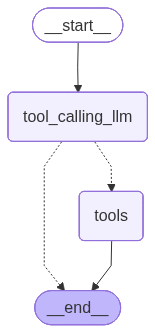

In [14]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_1a5069f2-6623-4e2e-8c91-0f1ade36de8f)
 Call ID: fc_1a5069f2-6623-4e2e-8c91-0f1ade36de8f
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [16]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_cb1a65bb-9c78-4836-b12a-d35404b8fb8e)
 Call ID: fc_cb1a65bb-9c78-4836-b12a-d35404b8fb8e
  Args:
    query: AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025 - The Artificial Intelligence Revolution - Choreo Advisors", "url": "https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution/", "content": "There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potential leader in the field. The ChatGPT 

In [17]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence that focuses on developing algorithms and statistical models that enable computers to *learn* from data—i.e., to automatically improve their performance on a specific task without being explicitly programmed for every possible scenario.

---

## Core Idea
1. **Data → Model → Prediction/Decision**  
   - **Data**: examples (e.g., images, text, sensor readings).  
   - **Model**: a mathematical structure (e.g., a neural network, decision tree, linear regression) with adjustable parameters.  
   - **Learning**: an optimization process (often minimizing a loss function) that tunes the parameters so the model’s output matches the observed data as well as possible.  
2. **Generalization**: After training, the model should perform well on *